In [30]:
# ── User-editable constants ──────────────────────────────────────────────────
WIDTH = 1297
HEIGHT = 840
DATA_PATH = "metrics/fgs--garden--splats_per_pixel.csv"

In [31]:
import pandas as pd

df = pd.read_csv(DATA_PATH, header=None)
counts = df.iloc[:, 0].to_numpy()

frame = counts[: WIDTH * HEIGHT].reshape(HEIGHT, WIDTH)

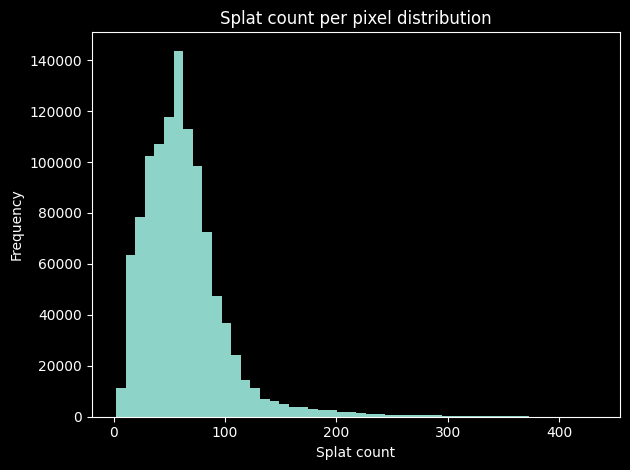

In [32]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(frame.ravel(), bins=50)
plt.xlabel("Splat count")
plt.ylabel("Frequency")
plt.title("Splat count per pixel distribution")
plt.tight_layout()
plt.show()

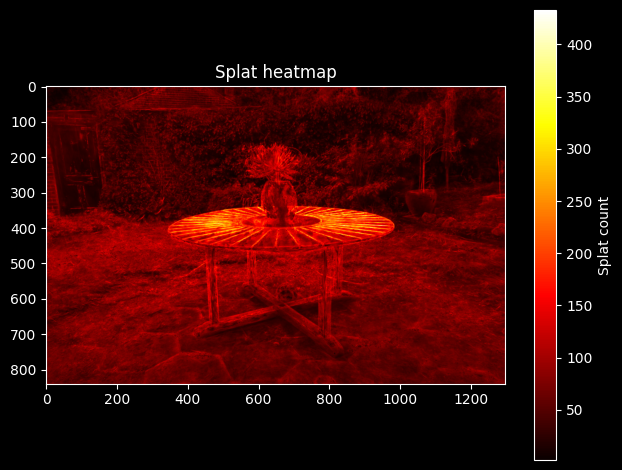

In [33]:
plt.figure()
plt.imshow(frame, cmap="hot", aspect="equal")
plt.colorbar(label="Splat count")
plt.title("Splat heatmap")
plt.tight_layout()
plt.show()

In [34]:
import pathlib

output_dir = pathlib.Path("heatmaps")
output_dir.mkdir(exist_ok=True)

n_frames = len(counts) // (WIDTH * HEIGHT)
for i in range(n_frames):
    f = counts[i * WIDTH * HEIGHT : (i + 1) * WIDTH * HEIGHT].reshape(HEIGHT, WIDTH)
    fig, ax = plt.subplots()
    im = ax.imshow(f, cmap="hot", aspect="equal")
    fig.colorbar(im, ax=ax, label="Splat count")
    ax.set_title(f"Splat heatmap (frame {i})")
    fig.tight_layout()
    fig.savefig(output_dir / f"{i}.png")
    plt.close(fig)